# Brain Tumor MRI — Multiclass Classification with ResNet50

This notebook trains a **multiclass** classifier (e.g., *glioma / meningioma / pituitary / no_tumor*) using **transfer learning** with **ResNet50** in **PyTorch**.

> Optimized for **Apple Silicon** using **MPS** acceleration when available.


## 0) Install (local)

On Apple Silicon, install PyTorch with MPS support:

```bash
pip install torch torchvision
pip install numpy pillow matplotlib
```


In [1]:
import os, json, time, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("torchvision:", __import__("torchvision").__version__)


torch: 2.10.0
torchvision: 0.25.0


## 1) Device: Apple Silicon (MPS)

We’ll use:
- `mps` if available (fast on Apple Silicon)
- else `cpu`


In [2]:
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
device


device(type='mps')

## 2) Configure paths + hyperparameters

Update `TRAIN_DIR` and (optionally) `TEST_DIR` to match your Kaggle dataset.

Common Kaggle structure:
- `.../Training/<class>/...`
- `.../Testing/<class>/...`

If you only have one folder with class subfolders, set `TRAIN_DIR` to that and set `TEST_DIR=None`.


In [3]:
# ====== CONFIG ======
IMG_SIZE = 224
BATCH = 32
SEED = 42
VAL_RATIO = 0.2

TRAIN_DIR = "dataset/Training"
TEST_DIR  = "dataset/Testing"

OUT_DIR = Path("models")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)


TRAIN_DIR: dataset/Training
TEST_DIR : dataset/Testing


## 3) Reproducibility

We seed Python, NumPy, and PyTorch for more stable results.


In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # MPS doesn't support deterministic ops the same way as CUDA

seed_everything(SEED)


## 4) Transforms (augmentation + normalization)

ResNet50 pretrained weights expect ImageNet normalization:
- mean = (0.485, 0.456, 0.406)
- std  = (0.229, 0.224, 0.225)

Augmentations are kept **light** (MRI images): small rotations, flips, mild color jitter.


In [5]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


## 5) Load dataset with `ImageFolder`

We load the full training dataset, then split into train/val.

> Note: `random_split` is not stratified. If you want a strict stratified split, tell me and I’ll swap in a stratified sampler/split.


In [6]:
# Load full training dataset (for splitting)
full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)

class_names = full_train.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Num classes:", num_classes)
print("Total images:", len(full_train))

val_size = int(len(full_train) * VAL_RATIO)
train_size = len(full_train) - val_size

train_ds, val_ds = random_split(
    full_train,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# IMPORTANT: validation should not use augmentation
# random_split returns Subset objects; we can override transform by wrapping:
val_ds.dataset = datasets.ImageFolder(TRAIN_DIR, transform=eval_tfms)


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Num classes: 4
Total images: 5600


## 6) DataLoaders

In [7]:
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)

test_loader = None
if TEST_DIR and os.path.isdir(TEST_DIR):
    test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_tfms)
    test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=0)
    print("Loaded test images:", len(test_ds))
else:
    print("No test set found (or TEST_DIR=None). We'll train + validate only.")


Loaded test images: 1600


## 7) Visual sanity-check

We’ll show a few *unnormalized* training images.


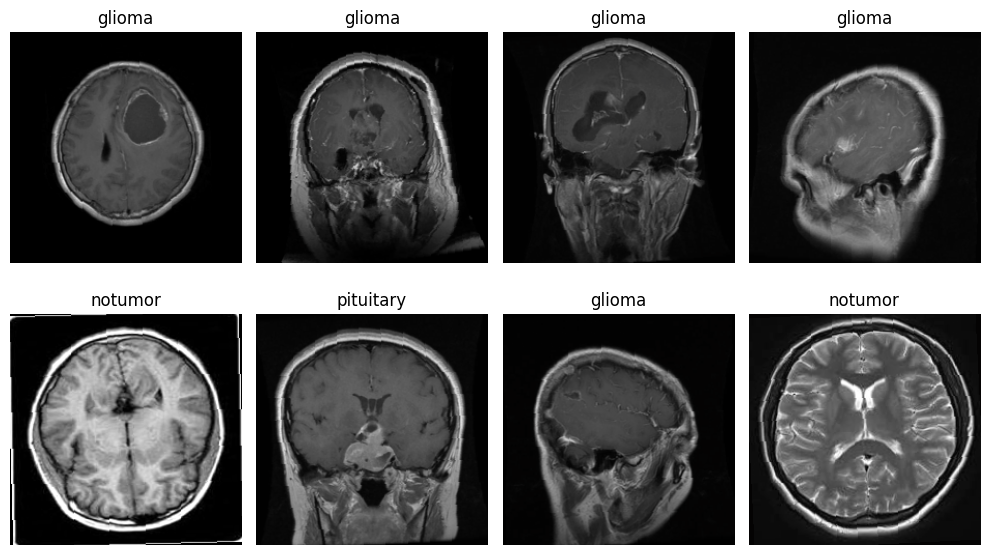

In [8]:
def denorm(img_t):
    # img_t: [C,H,W]
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    x = img_t.cpu() * std + mean
    return torch.clamp(x, 0, 1)

# Grab one batch
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,6))
for i in range(min(8, images.size(0))):
    ax = plt.subplot(2,4,i+1)
    plt.imshow(denorm(images[i]).permute(1,2,0))
    plt.title(class_names[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()


## 8) Build ResNet50 (transfer learning)

Phase 1: freeze the backbone, train only the final classifier layer.  
Phase 2: unfreeze the last block(s), fine-tune with a low learning rate.


In [18]:
# Load pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Replace final layer for our classes
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)


## 9) Training utilities

In [10]:
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses, accs = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, y))
    return float(np.mean(losses)), float(np.mean(accs))

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses, accs = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, y))
    return float(np.mean(losses)), float(np.mean(accs))


## 10) Phase 1 — Train head (freeze backbone)

We freeze all layers **except** the final `fc`.


In [11]:
# Freeze backbone
for name, param in model.named_parameters():
    param.requires_grad = name.startswith("fc.")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

EPOCHS_1 = 5

for epoch in range(1, EPOCHS_1 + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    dt = time.time() - t0

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"[Phase1][{epoch}/{EPOCHS_1}] "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} | {dt:.1f}s")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), OUT_DIR / "best_phase1.pt")

print("Best val acc (phase1):", best_val_acc)


[Phase1][1/5] train loss 0.7605 acc 0.7779 | val loss 0.5557 acc 0.8393 | 95.3s
[Phase1][2/5] train loss 0.4681 acc 0.8500 | val loss 0.4523 acc 0.8625 | 88.4s
[Phase1][3/5] train loss 0.4144 acc 0.8618 | val loss 0.4023 acc 0.8670 | 96.4s
[Phase1][4/5] train loss 0.3726 acc 0.8772 | val loss 0.3884 acc 0.8688 | 93.5s
[Phase1][5/5] train loss 0.3487 acc 0.8842 | val loss 0.3629 acc 0.8741 | 98.7s
Best val acc (phase1): 0.8741071428571429


## 11) Phase 2 — Fine-tune (unfreeze last layers)

We unfreeze ResNet’s `layer4` (last block) + `fc`, and fine-tune with a smaller LR.


In [12]:
# Unfreeze last block + fc
for name, param in model.named_parameters():
    if name.startswith("layer4.") or name.startswith("fc."):
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

EPOCHS_2 = 5
best_val_acc_2 = best_val_acc

for epoch in range(1, EPOCHS_2 + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    dt = time.time() - t0

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"[Phase2][{epoch}/{EPOCHS_2}] "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} | {dt:.1f}s")

    if va_acc > best_val_acc_2:
        best_val_acc_2 = va_acc
        torch.save(model.state_dict(), OUT_DIR / "best.pt")

print("Best val acc (final):", best_val_acc_2)


[Phase2][1/5] train loss 0.2960 acc 0.8958 | val loss 0.3117 acc 0.8911 | 127.4s
[Phase2][2/5] train loss 0.2629 acc 0.9049 | val loss 0.2802 acc 0.8946 | 141.2s
[Phase2][3/5] train loss 0.2283 acc 0.9190 | val loss 0.2628 acc 0.9045 | 152.0s
[Phase2][4/5] train loss 0.2065 acc 0.9228 | val loss 0.2359 acc 0.9170 | 147.4s
[Phase2][5/5] train loss 0.1969 acc 0.9257 | val loss 0.2323 acc 0.9170 | 179.4s
Best val acc (final): 0.9169642857142857


## 12) Plot training curves

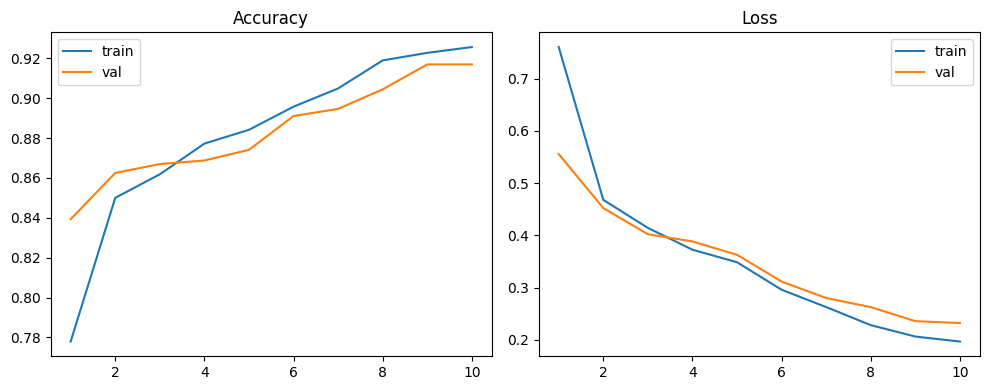

In [13]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()


## 13) Test evaluation & confusion matrix

Loaded best model weights: models/best.pt
Test loss: 0.4135
Test acc : 0.8638


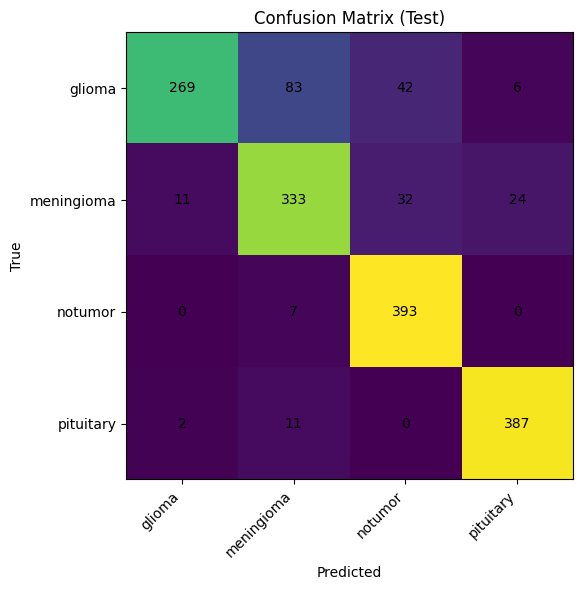

In [14]:
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    all_y = []
    all_p = []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_p.append(preds)
        all_y.append(y.numpy())
    return np.concatenate(all_y), np.concatenate(all_p)

def confusion_matrix_np(y_true, y_pred, k):
    cm = np.zeros((k, k), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

if test_loader is not None:
    # Load best weights if saved
    best_path = OUT_DIR / "best.pt"
    if best_path.exists():
        model.load_state_dict(torch.load(best_path, map_location="cpu"))
        model = model.to(device)
        print("Loaded best model weights:", best_path)

    test_loss, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test loss: {test_loss:.4f}")
    print(f"Test acc : {test_acc:.4f}")

    y_true, y_pred = predict_all(model, test_loader)
    cm = confusion_matrix_np(y_true, y_pred, num_classes)

    plt.figure(figsize=(6,6))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix (Test)")
    plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
    plt.yticks(range(num_classes), class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()
else:
    print("No test_loader. Provide TEST_DIR to run test evaluation.")


## 14) Save artifacts for Streamlit

We save:
- `models/model.pt` → PyTorch weights
- `models/class_names.json` → label mapping (index → class name)

In Streamlit you will:
- build the same ResNet50 model architecture
- load `model.pt`
- use `class_names.json` to map predictions to labels


In [15]:
# Load best weights if present
best_path = OUT_DIR / "best.pt"
if best_path.exists():
    model.load_state_dict(torch.load(best_path, map_location="cpu"))
    model = model.to(device)
    print("Loaded best model weights:", best_path)

torch.save(model.state_dict(), OUT_DIR / "model.pt")

with open(OUT_DIR / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False)

print("Saved:", OUT_DIR / "model.pt")
print("Saved:", OUT_DIR / "class_names.json")


Loaded best model weights: models/best.pt
Saved: models/model.pt
Saved: models/class_names.json


## 15) (Optional) Single-image prediction helper

Use this to test quickly inside the notebook.


In [16]:
from PIL import Image

@torch.no_grad()
def predict_one_image(path):
    img = Image.open(path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(device)
    model.eval()
    logits = model(x)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    top = probs.argmax()
    return class_names[top], float(probs[top]), probs

# Example:
# label, conf, probs = predict_one_image("some_mri.png")
# print(label, conf)


## Next: Continue on Streamlit app (PyTorch)